In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# --- PRÉPARATION DES DONNÉES ---
# X : Matrice des caractéristiques (Notes sur 20)
# y : Vecteur cible (Classe : Réussite ou Échec)
etudiants_base = [
    [15,12,14,13,16,15], [8,9,7,10,8,9], [12,11,13,14,12,10], [5,6,7,8,5,6],
    [17,14,16,15,18,17], [9,10,8,9,11,10], [13,12,11,14,13,12], [4,5,6,5,4,5],
    [16,15,14,17,16,18], [7,8,9,7,8,7], [11,10,12,11,10,11], [6,7,5,6,7,6],
    [14,13,15,14,13,14], [10,9,10,11,9,10], [18,17,16,18,17,18], [3,4,5,4,3,4],
    [12,13,12,11,14,13], [8,7,8,9,7,8], [15,16,15,14,15,16], [5,5,6,5,6,5]
]

# Ajout de la 7ème matière : Électronique numérique
X_ext = [e + [int(np.clip(np.mean(e) + (sum(e) % 5 - 2), 4, 18))] for e in etudiants_base]
X = np.array(X_ext)

features = [
    "Probabilité & Stat", "Algo 2", "Langage C",
    "Anglais", "Architecture 2", "Systèmes d’exploitation 2", "Électronique numérique"
]

# Calcul de la cible : Si moyenne >= 10 alors "Réussite", sinon "Échec"
y = np.array(["Réussite" if np.mean(e) >= 10 else "Échec" for e in X])

In [7]:
def entropie(labels):
    """
    CALCUL DE L'ENTROPIE DE SHANNON : H(S) = - Σ (p_i * log2(p_i))
    L'entropie mesure le désordre (l'impureté) d'un ensemble de données.
    - Si H(S) = 0 : L'ensemble est pur (tous les étudiants ont réussi ou tous ont échoué).
    - Si H(S) = 1 : Le mélange est maximal (50% Réussite / 50% Échec).
    """
    total = len(labels)
    if total == 0: return 0

    compteur = Counter(labels)
    h = 0
    for v in compteur.values():
        p = v / total  # p_i : proportion de la classe i dans le groupe
        h -= p * math.log2(p)
    return h

def split_dataset(X, y, f, s):
    """
    DIVISION BINAIRE (SPLIT)
    Sépare l'ensemble en deux groupes selon une matière (f) et un seuil (s).
    Gauche : note <= seuil | Droite : note > seuil
    """
    mask = X[:, f] <= s
    return X[mask], y[mask], X[~mask], y[~mask]

def information_gain(p_labels, g_labels, d_labels):
    """
    GAIN D'INFORMATION : IG(S, f) = H(S) - Σ (|S_v| / |S|) * H(S_v)
    Le but de CART est de maximiser ce gain.
    On soustrait à l'entropie initiale (H(S)) la somme pondérée de l'entropie
    des deux nouveaux groupes (gauche et droite).
    Plus le gain est élevé, plus la matière choisie est "discriminante".
    """
    total = len(p_labels)
    # Entropie pondérée des enfants
    h_pond = (len(g_labels)/total)*entropie(g_labels) + (len(d_labels)/total)*entropie(d_labels)
    return entropie(p_labels) - h_pond

In [8]:
def executer_analyse(X, y):
    gains_par_module = []
    m_gain_global = -1
    m_feat_global = None
    m_seuil_global = None

    # H(S) initial
    h_initiale = entropie(y)
    print(f"--- ANALYSE CART ---")
    print(f"Entropie initiale H(S): {round(h_initiale, 4)}\n")

    # On teste chaque matière (f)
    for f in range(X.shape[1]):
        best_gain_f = -1
        # On teste chaque note unique comme seuil potentiel (s)
        for s in np.unique(X[:, f]):
            gx, gy, dx, dy = split_dataset(X, y, f, s)
            if len(gy) > 0 and len(dy) > 0:
                gain = information_gain(y, gy, dy)
                if gain > best_gain_f:
                    best_gain_f = gain

                # Enregistrement du meilleur split absolu pour l'arbre
                if gain > m_gain_global:
                    m_gain_global, m_feat_global, m_seuil_global = gain, f, s

        gains_par_module.append(best_gain_f)

    # --- AFFICHAGE DES RÉSULTATS ---
    print("RÉSULTAT GLOBAL")
    print(f"Meilleur module : {features[m_feat_global]}")
    print(f"Seuil : {m_seuil_global}")
    print(f"Gain max : {round(m_gain_global, 4)}")
    print("-" * 40)

    print("\n--- GAINS PAR MODULE ---")
    for i, g in enumerate(gains_par_module):
        print(f"{features[i]} : Gain = {round(g, 4)}")

    print(f"\n MEILLEUR MODULE GLOBAL : {features[m_feat_global]}")
    return m_feat_global

# Lancement de l'analyse
best_feature_idx = executer_analyse(X, y)

--- ANALYSE CART ---
Entropie initiale H(S): 0.9928

RÉSULTAT GLOBAL
Meilleur module : Probabilité & Stat
Seuil : 9
Gain max : 0.9928
----------------------------------------

--- GAINS PAR MODULE ---
Probabilité & Stat : Gain = 0.9928
Algo 2 : Gain = 0.6166
Langage C : Gain = 0.9928
Anglais : Gain = 0.9928
Architecture 2 : Gain = 0.7445
Systèmes d’exploitation 2 : Gain = 0.7445
Électronique numérique : Gain = 0.7583

 MEILLEUR MODULE GLOBAL : Probabilité & Stat


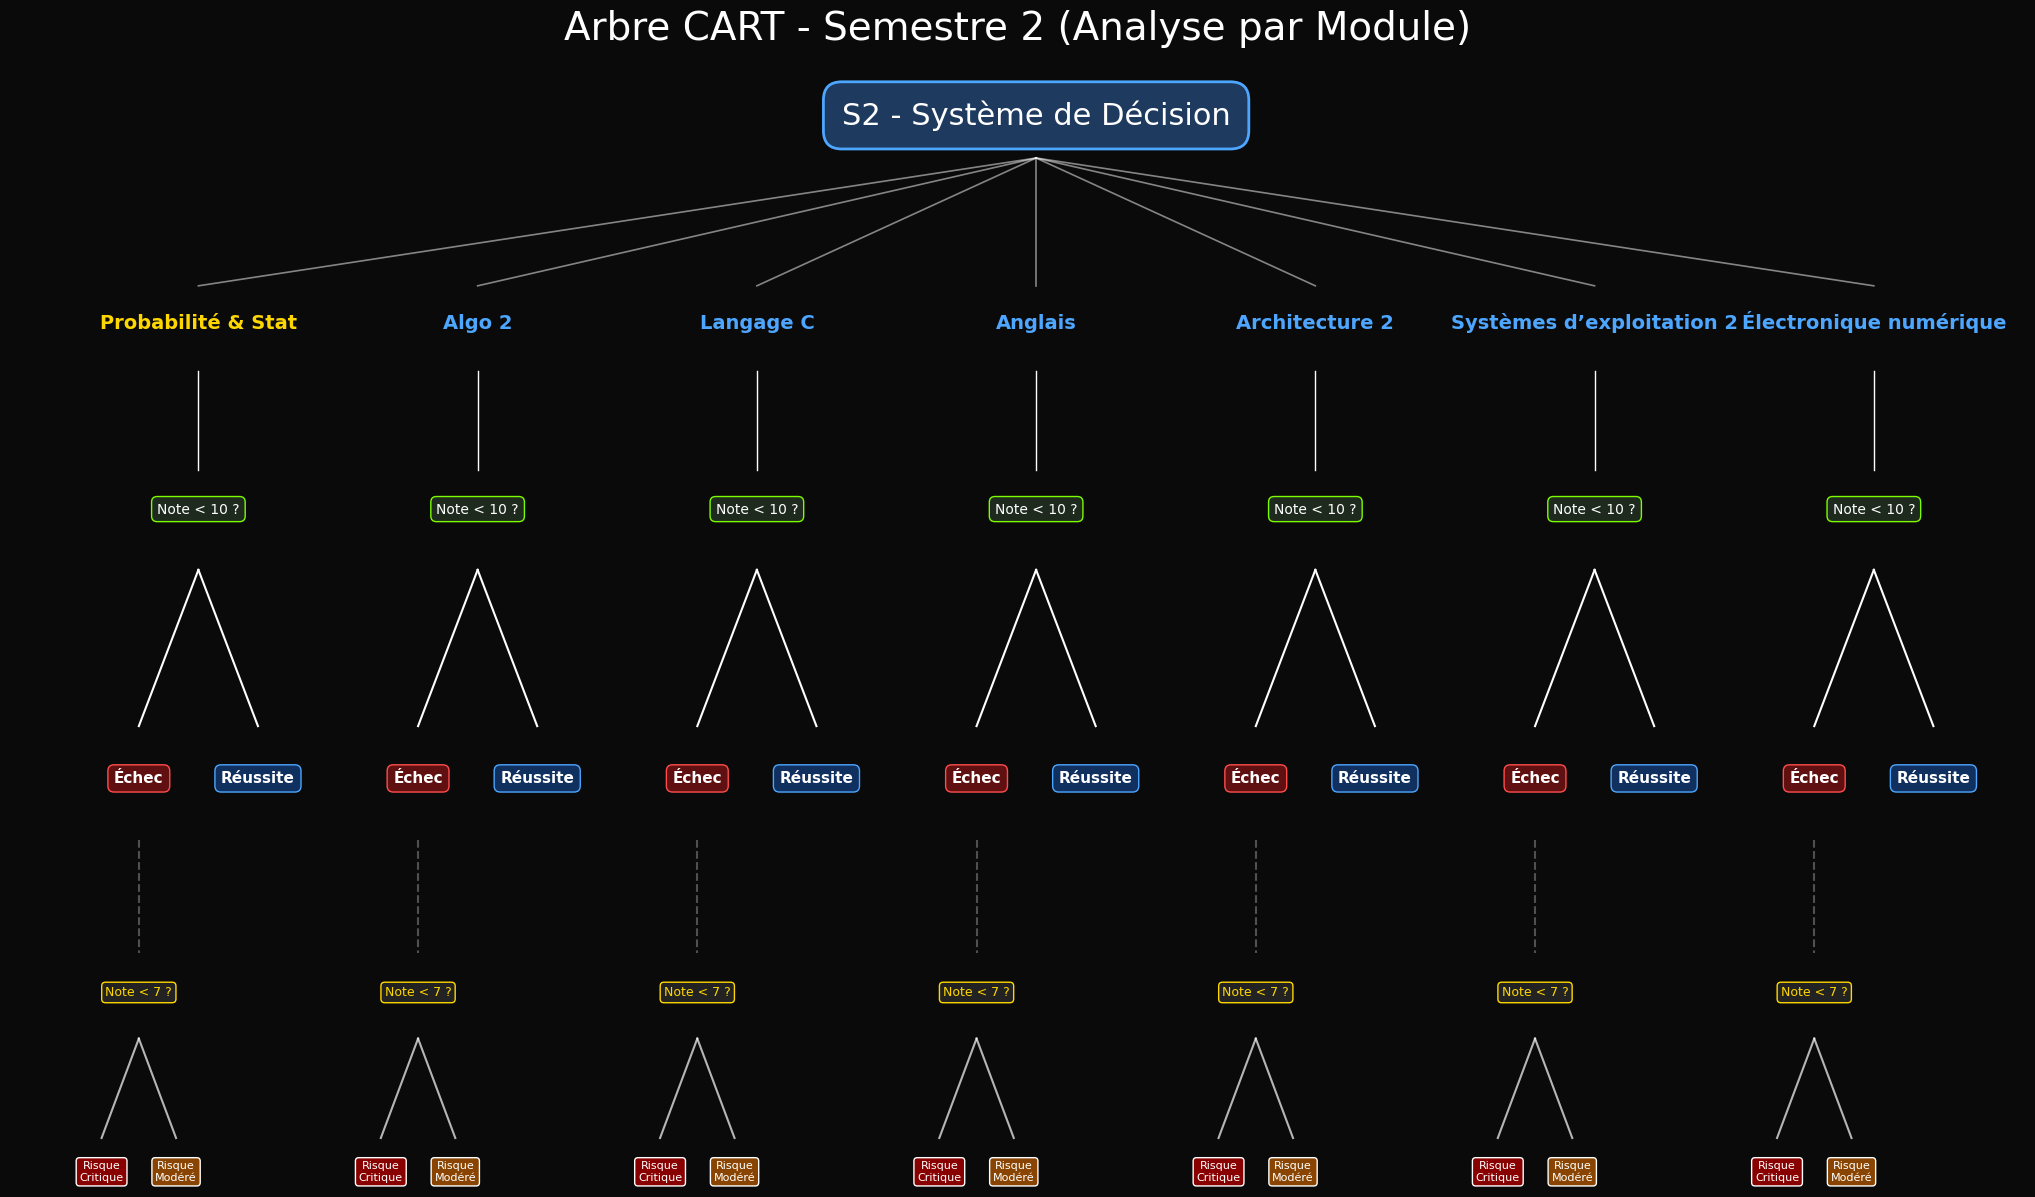

In [9]:
# --- GÉNÉRATION DU GRAPHIQUE ---
fig, ax = plt.subplots(figsize=(26, 14))
fig.patch.set_facecolor("#0A0A0A")
ax.set_facecolor("#0A0A0A")
ax.axis('off')

plt.title("Arbre CART - Semestre 2 (Analyse par Module)", fontsize=28, color='white', pad=50)

# Racine
ax.text(0.5, 0.95, "S2 - Système de Décision", ha='center', va='center', fontsize=22, color='white',
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

pos = np.linspace(0.05, 0.95, len(features))

for i, mod in enumerate(features):
    x = pos[i]
    color_text = "#FFD700" if i == best_feature_idx else "#4DA6FF"

    # Dessin des branches et des nœuds
    ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.2, alpha=0.5)
    ax.text(x, 0.80, mod, ha='center', fontsize=14, fontweight='bold', color=color_text)

    # Test "Note < 10"
    ax.plot([x, x], [0.77, 0.70], color='white', linewidth=1)
    ax.text(x, 0.67, "Note < 10 ?", ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#1F2A1F", edgecolor="#7CFC00"))

    # Feuilles finales
    xl, xr = x-0.032, x+0.032
    ax.plot([x, xl], [0.63, 0.52], color='white')
    ax.plot([x, xr], [0.63, 0.52], color='white')

    ax.text(xl, 0.48, "Échec", ha='center', fontsize=11, fontweight='bold', color='white',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#601010", edgecolor="#FF4D4D"))
    ax.text(xr, 0.48, "Réussite", ha='center', fontsize=11, fontweight='bold', color='white',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#103060", edgecolor="#4DA6FF"))

    # Sous-analyse (Risque)
    ax.plot([xl, xl], [0.44, 0.36], color='gray', linestyle='--', alpha=0.6)
    ax.text(xl, 0.33, "Note < 7 ?", ha='center', fontsize=9, color='#FFD700',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222", edgecolor="#FFD700"))

    xrl, xrr = xl-0.02, xl+0.02
    ax.plot([xl, xrl], [0.30, 0.23], color='white', alpha=0.7)
    ax.plot([xl, xrr], [0.30, 0.23], color='white', alpha=0.7)

    ax.text(xrl, 0.20, "Risque\nCritique", ha='center', fontsize=8, color='white',
            bbox=dict(boxstyle="round", facecolor="#880000"))
    ax.text(xrr, 0.20, "Risque\nModéré", ha='center', fontsize=8, color='white',
            bbox=dict(boxstyle="round", facecolor="#884400"))

plt.show()